In [11]:
import sys
import os
import time

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from preprocessing.preprocess import preprocess
from models.KNN_optimized import KNNClassifier

import evaluation.multiclass_metrics as mm

# Phase 2: Multiclass KNN Classification

This notebook extends KNN from binary classification to multiclass classification.

The model classifies MNIST digits from 0 to 9.

Phase 2 includes three improvements:
1. Feature engineering using Flatten, PCA, and HOG
2. Hyperparameter tuning for k
3. Overfitting / underfitting diagnosis using training and validation accuracy

In [12]:
def evaluate_multiclass_results(y_true, y_pred, model_name):
    acc = mm.accuracy(y_true, y_pred)
    prec = mm.precision_macro(y_true, y_pred)
    rec = mm.recall_macro(y_true, y_pred)
    f1 = mm.f1_macro(y_true, y_pred)
    cm = mm.confusion_matrix(y_true, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("Confusion Matrix:\n", cm)

    return acc, prec, rec, f1, cm

In [13]:
def save_multiclass_confusion_matrix(cm, title, save_path):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")

    for i in range(10):
        for j in range(10):
            plt.text(
                j, i, cm[i, j],
                ha="center",
                va="center",
                fontsize=7
            )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(range(10))
    plt.yticks(range(10))

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

## PCA Preprocessing for Hyperparameter Tuning

PCA is used first for tuning because it reduces feature dimensionality and makes KNN faster.

The preprocessing pipeline handles loading data, normalization, multiclass labels, PCA feature extraction, train/validation split, and standardization.

In [14]:
X_tr_pca, X_val_pca, X_test_pca, y_tr_pca, y_val_pca, y_test_pca = preprocess(
    feature_method="pca",
    binary=False,
    pca_components=50
)

print("Train:", X_tr_pca.shape, y_tr_pca.shape)
print("Validation:", X_val_pca.shape, y_val_pca.shape)
print("Test:", X_test_pca.shape, y_test_pca.shape)

 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 1.0000

 Preprocessing Pipeline Complete!
   

## Improvement 1: Hyperparameter Tuning

KNN depends on the value of k, which controls the number of nearest neighbors used for prediction.

We test different k values and choose the best one based on validation accuracy.

In [15]:
k_values = [1, 3, 5, 7]
cv_results = {}

for k in k_values:
    print(f"\nTesting k = {k}")

    knn_cv = KNNClassifier(k=k, batch_size=500)
    knn_cv.fit(X_tr_pca, y_tr_pca)

    y_val_pred_cv = knn_cv.predict(X_val_pca)

    acc = mm.accuracy(y_val_pca, y_val_pred_cv)

    cv_results[k] = acc

    print("Validation Accuracy:", acc)

best_k = max(cv_results, key=cv_results.get)

print("\nBest k:", best_k)
print("Best validation accuracy:", cv_results[best_k])


Testing k = 1
Validation Accuracy: 0.9661666666666666

Testing k = 3
Validation Accuracy: 0.9666666666666667

Testing k = 5
Validation Accuracy: 0.9659166666666666

Testing k = 7
Validation Accuracy: 0.9645

Best k: 3
Best validation accuracy: 0.9666666666666667


## Improvement 2: Overfitting / Underfitting Diagnosis

To diagnose overfitting and underfitting, training accuracy and validation accuracy are compared for different k values.

Small k values may overfit, while larger k values may underfit.

In [16]:
train_accuracies = []
val_accuracies = []

for k in k_values:
    print(f"\nChecking k = {k}")

    knn_diag = KNNClassifier(k=k, batch_size=500)
    knn_diag.fit(X_tr_pca, y_tr_pca)

    y_train_pred_diag = knn_diag.predict(X_tr_pca)
    y_val_pred_diag = knn_diag.predict(X_val_pca)

    train_acc = mm.accuracy(y_tr_pca, y_train_pred_diag)
    val_acc = mm.accuracy(y_val_pca, y_val_pred_diag)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"k={k} | Train Accuracy={train_acc:.4f} | Validation Accuracy={val_acc:.4f}")


Checking k = 1
k=1 | Train Accuracy=1.0000 | Validation Accuracy=0.9662

Checking k = 3
k=3 | Train Accuracy=0.9830 | Validation Accuracy=0.9667

Checking k = 5
k=5 | Train Accuracy=0.9773 | Validation Accuracy=0.9659

Checking k = 7
k=7 | Train Accuracy=0.9740 | Validation Accuracy=0.9645


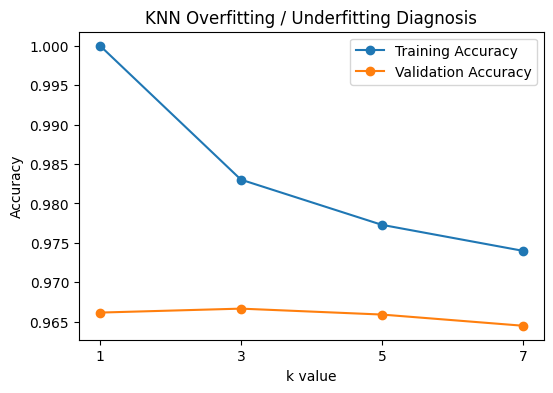

In [17]:
os.makedirs("../results/phase2", exist_ok=True)

plt.figure(figsize=(6, 4))

plt.plot(k_values, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(k_values, val_accuracies, marker="o", label="Validation Accuracy")

plt.title("KNN Overfitting / Underfitting Diagnosis")
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.legend()

plt.savefig("../results/phase2/knn_overfitting_underfitting_curve.png", bbox_inches="tight")
plt.show()

In [18]:
with open("../results/phase2/knn_k_tuning_results.txt", "w") as f:
    f.write("KNN Hyperparameter Tuning Results\n")
    f.write("=" * 45 + "\n\n")

    for k, acc in cv_results.items():
        f.write(f"k = {k} | Validation Accuracy = {acc:.4f}\n")

    f.write("\n")
    f.write(f"Best k = {best_k}\n")
    f.write(f"Best Validation Accuracy = {cv_results[best_k]:.4f}\n\n")

    f.write("Overfitting / Underfitting Diagnosis\n")
    f.write("-" * 45 + "\n")

    for k, train_acc, val_acc in zip(k_values, train_accuracies, val_accuracies):
        f.write(
            f"k = {k} | Training Accuracy = {train_acc:.4f} | Validation Accuracy = {val_acc:.4f}\n"
        )

print("K tuning results saved.")

K tuning results saved.


## Improvement 3: Feature Engineering — Flatten Features

Flattening converts each 28×28 image into a one-dimensional vector.

This is the baseline feature representation.

In [19]:
X_tr_flat, X_val_flat, X_test_flat, y_tr_flat, y_val_flat, y_test_flat = preprocess(
    feature_method="flatten",
    binary=False
)

print("Train:", X_tr_flat.shape, y_tr_flat.shape)
print("Validation:", X_val_flat.shape, y_val_flat.shape)
print("Test:", X_test_flat.shape, y_test_flat.shape)

 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 784)  y_tr   : (48000,)
   X_val  : (12000, 784)  y_val  : (12000,)
   X_test : (10000, 784)  y_test : (10000,)
Train: (48000, 784)

In [20]:
knn_flat = KNNClassifier(k=3, batch_size=500)

start = time.time()
knn_flat.fit(X_tr_flat, y_tr_flat)
flat_train_time = time.time() - start

print("Flatten model trained.")
print("Training time:", flat_train_time)

Flatten model trained.
Training time: 0.02807474136352539


In [21]:
start = time.time()
y_val_pred_flat = knn_flat.predict(X_val_flat)
flat_val_time = time.time() - start

flat_val_acc, flat_val_prec, flat_val_rec, flat_val_f1, flat_val_cm = evaluate_multiclass_results(
    y_val_flat,
    y_val_pred_flat,
    "KNN Flatten Validation"
)

print("Validation time:", flat_val_time)

KNN Flatten Validation
Accuracy : 0.9465
Precision: 0.9466925445028455
Recall   : 0.9458148461669881
F1-score : 0.9459739163845418
Confusion Matrix:
 [[1160    0    1    1    1    1    8    1    1    1]
 [   0 1311    7    0    1    0    2    0    0    1]
 [  13   13 1100   18    4    2   11    8    3    2]
 [   1    1   18 1156    0   19    1    9   10    4]
 [   2   13   13    1 1102    1    2    4    0   38]
 [  13    3    3   38    2 1011   13    2   14    5]
 [  10    4    4    0    1    5 1153    0    0    0]
 [   1   17    7    7   12    0    0 1214    1   40]
 [   8   10   11   24   13   38    4    6 1036   10]
 [   4    1    9   11   18    1    0   32    3 1115]]
Validation time: 7.297794580459595


In [22]:
start = time.time()
y_test_pred_flat = knn_flat.predict(X_test_flat)
flat_test_time = time.time() - start

flat_test_acc, flat_test_prec, flat_test_rec, flat_test_f1, flat_test_cm = evaluate_multiclass_results(
    y_test_flat,
    y_test_pred_flat,
    "KNN Flatten Test"
)

print("Test time:", flat_test_time)

KNN Flatten Test
Accuracy : 0.9447
Precision: 0.9449210278544191
Recall   : 0.9439394638462663
F1-score : 0.9441177903371987
Confusion Matrix:
 [[ 967    0    1    3    0    4    5    0    0    0]
 [   0 1128    3    0    1    0    3    0    0    0]
 [  13    8  967   19    0    0    6    9    8    2]
 [   0    3    6  963    2   14    3    9    8    2]
 [   1   11    4    2  927    1    7    4    2   23]
 [   7    1    5   21    6  824   11    2    6    9]
 [  13    4    2    0    3    9  926    0    1    0]
 [   0   24    9    5    8    2    0  950    1   29]
 [  13    4    9   26   10   29    1    7  867    8]
 [   7    6    4   13   14    3    0   30    4  928]]
Test time: 6.10629940032959


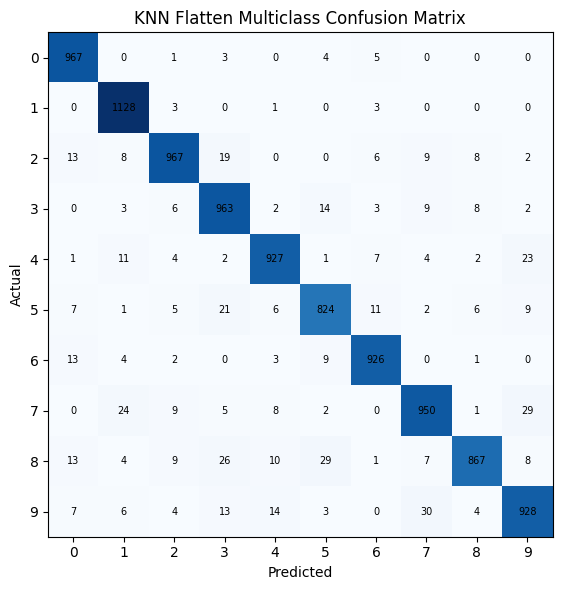

Flatten results saved.


In [23]:
os.makedirs("../results/phase2", exist_ok=True)

save_multiclass_confusion_matrix(
    flat_test_cm,
    "KNN Flatten Multiclass Confusion Matrix",
    "../results/phase2/knn_flatten_confusion_matrix.png"
)

with open("../results/phase2/knn_flatten_results.txt", "w") as f:
    f.write("KNN Flatten Phase 2 Results\n")
    f.write("=" * 40 + "\n\n")
    f.write(f"Validation Accuracy: {flat_val_acc:.4f}\n")
    f.write(f"Test Accuracy      : {flat_test_acc:.4f}\n")
    f.write(f"Precision          : {flat_test_prec:.4f}\n")
    f.write(f"Recall             : {flat_test_rec:.4f}\n")
    f.write(f"F1-score           : {flat_test_f1:.4f}\n\n")
    f.write("Test Confusion Matrix:\n")
    f.write(str(flat_test_cm))
    f.write("\n\n")
    f.write(f"Train time: {flat_train_time:.4f}\n")
    f.write(f"Validation time: {flat_val_time:.4f}\n")
    f.write(f"Test time: {flat_test_time:.4f}\n")

print("Flatten results saved.")

## PCA Features

PCA reduces feature dimensionality while preserving important information.

This helps KNN run faster and reduces the effect of noisy pixel-level features.

In [24]:
X_tr_pca, X_val_pca, X_test_pca, y_tr_pca, y_val_pca, y_test_pca = preprocess(
    feature_method="pca",
    binary=False,
    pca_components=50
)

print("Train:", X_tr_pca.shape, y_tr_pca.shape)
print("Validation:", X_val_pca.shape, y_val_pca.shape)
print("Test:", X_test_pca.shape, y_test_pca.shape)

 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 1.0000

 Preprocessing Pipeline Complete!
   

In [25]:
knn_pca = KNNClassifier(k=3, batch_size=500)

start = time.time()
knn_pca.fit(X_tr_pca, y_tr_pca)
pca_train_time = time.time() - start

print("PCA model trained.")
print("Training time:", pca_train_time)

PCA model trained.
Training time: 0.001972198486328125


In [26]:
start = time.time()
y_val_pred_pca = knn_pca.predict(X_val_pca)
pca_val_time = time.time() - start

pca_val_acc, pca_val_prec, pca_val_rec, pca_val_f1, pca_val_cm = evaluate_multiclass_results(
    y_val_pca,
    y_val_pred_pca,
    "KNN PCA Validation"
)

print("Validation time:", pca_val_time)

KNN PCA Validation
Accuracy : 0.9666666666666667
Precision: 0.9671437455839763
Recall   : 0.9661514626204278
F1-score : 0.9664297615072996
Confusion Matrix:
 [[1164    0    0    2    0    2    6    0    0    1]
 [   0 1316    3    0    1    0    0    0    0    2]
 [   9   11 1125    3    0    1    1   19    4    1]
 [   2    0   15 1170    0   14    0    5    8    5]
 [   1   11    2    0 1125    0    2    3    0   32]
 [   2    7    2   17    0 1059    9    1    5    2]
 [   0    4    3    0    1    2 1167    0    0    0]
 [   2   19    5    0    6    0    0 1264    0    3]
 [   6   19   13   19   10   17    7    4 1059    6]
 [  10    3    2    3   12    4    1    8    0 1151]]
Validation time: 5.669213056564331


In [27]:
start = time.time()
y_test_pred_pca = knn_pca.predict(X_test_pca)
pca_test_time = time.time() - start

pca_test_acc, pca_test_prec, pca_test_rec, pca_test_f1, pca_test_cm = evaluate_multiclass_results(
    y_test_pca,
    y_test_pred_pca,
    "KNN PCA Test"
)

print("Test time:", pca_test_time)

KNN PCA Test
Accuracy : 0.9647
Precision: 0.965014310557075
Recall   : 0.9643002503925542
F1-score : 0.9644633042021136
Confusion Matrix:
 [[ 973    1    0    0    0    1    4    1    0    0]
 [   0 1128    3    0    1    0    2    0    0    1]
 [  17    6  984    3    3    0    0   13    6    0]
 [   1    2    4  972    1   18    0    7    4    1]
 [   2   10    1    0  943    0    6    2    1   17]
 [   2    1    0   13    3  856    8    1    4    4]
 [   8    4    1    0    2    4  939    0    0    0]
 [   0   22    6    0    4    1    0  989    0    6]
 [   8    7    5   24    8   16    3    3  896    4]
 [   3    4    4    5    8    4    1   11    2  967]]
Test time: 4.88167929649353


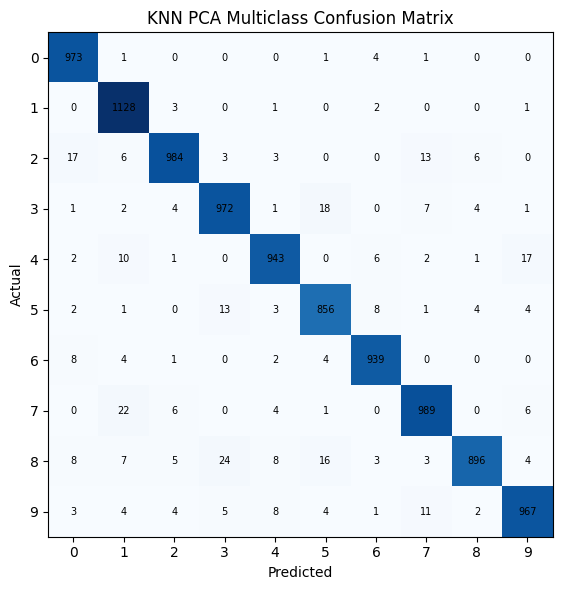

PCA results saved.


In [28]:
save_multiclass_confusion_matrix(
    pca_test_cm,
    "KNN PCA Multiclass Confusion Matrix",
    "../results/phase2/knn_pca_confusion_matrix.png"
)

with open("../results/phase2/knn_pca_results.txt", "w") as f:
    f.write("KNN PCA Phase 2 Results\n")
    f.write("=" * 40 + "\n\n")
    f.write(f"Validation Accuracy: {pca_val_acc:.4f}\n")
    f.write(f"Test Accuracy      : {pca_test_acc:.4f}\n")
    f.write(f"Precision          : {pca_test_prec:.4f}\n")
    f.write(f"Recall             : {pca_test_rec:.4f}\n")
    f.write(f"F1-score           : {pca_test_f1:.4f}\n\n")
    f.write("Test Confusion Matrix:\n")
    f.write(str(pca_test_cm))
    f.write("\n\n")
    f.write(f"Train time: {pca_train_time:.4f}\n")
    f.write(f"Validation time: {pca_val_time:.4f}\n")
    f.write(f"Test time: {pca_test_time:.4f}\n")

print("PCA results saved.")

## HOG Features

HOG extracts edge and gradient information from images.

This feature representation focuses on digit shape and stroke direction instead of raw pixel values.

In [29]:
X_tr_hog, X_val_hog, X_test_hog, y_tr_hog, y_val_hog, y_test_hog = preprocess(
    feature_method="hog",
    binary=False
)

print("Train:", X_tr_hog.shape, y_tr_hog.shape)
print("Validation:", X_val_hog.shape, y_val_hog.shape)
print("Test:", X_test_hog.shape, y_test_hog.shape)

 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 0.9943

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 441)  y_tr   : (48000,)
   X_v

In [30]:
knn_hog = KNNClassifier(k=3, batch_size=500)

start = time.time()
knn_hog.fit(X_tr_hog, y_tr_hog)
hog_train_time = time.time() - start

print("HOG model trained.")
print("Training time:", hog_train_time)

HOG model trained.
Training time: 0.017981767654418945


In [31]:
start = time.time()
y_val_pred_hog = knn_hog.predict(X_val_hog)
hog_val_time = time.time() - start

hog_val_acc, hog_val_prec, hog_val_rec, hog_val_f1, hog_val_cm = evaluate_multiclass_results(
    y_val_hog,
    y_val_pred_hog,
    "KNN HOG Validation"
)

print("Validation time:", hog_val_time)

KNN HOG Validation
Accuracy : 0.9358333333333333
Precision: 0.9373813100865664
Recall   : 0.9349967319093778
F1-score : 0.935521019380313
Confusion Matrix:
 [[1146    6    4    0    0    2   17    0    0    0]
 [   0 1311    5    0    1    0    2    2    1    0]
 [  10   22 1097   19    8    0    5    8    3    2]
 [   5    5   19 1148    0   16    2   14    2    8]
 [   3   30   14    2 1054    2    5    6    3   57]
 [  10    5    1   49    3  998   19    0   18    1]
 [  13    6    8    0    3    5 1140    0    2    0]
 [   3   27    7    5   14    0    0 1196    0   47]
 [  13   40   12   17   16   22    5    6 1018   11]
 [   4    4    8    2   16    5    0   30    3 1122]]
Validation time: 6.650987386703491


In [32]:
start = time.time()
y_test_pred_hog = knn_hog.predict(X_test_hog)
hog_test_time = time.time() - start

hog_test_acc, hog_test_prec, hog_test_rec, hog_test_f1, hog_test_cm = evaluate_multiclass_results(
    y_test_hog,
    y_test_pred_hog,
    "KNN HOG Test"
)

print("Test time:", hog_test_time)

KNN HOG Test
Accuracy : 0.9341
Precision: 0.9361067651420859
Recall   : 0.9331827458181594
F1-score : 0.9338798672797374
Confusion Matrix:
 [[ 963    2    2    1    0    3    9    0    0    0]
 [   1 1124    4    0    0    0    4    2    0    0]
 [  19   21  940   27    3    0    4   12    6    0]
 [   2    2   15  961    1   13    3    8    2    3]
 [   1   25    8    3  889    0    6    8    3   39]
 [   3    3    1   45    4  803   18    1    9    5]
 [   8    8    4    1    3    4  927    0    3    0]
 [   0   27   13   11   12    1    0  927    3   34]
 [  24   15   10   18   12   13    6    8  863    5]
 [   5   12    3   15   10    1    0   18    1  944]]
Test time: 5.361741065979004


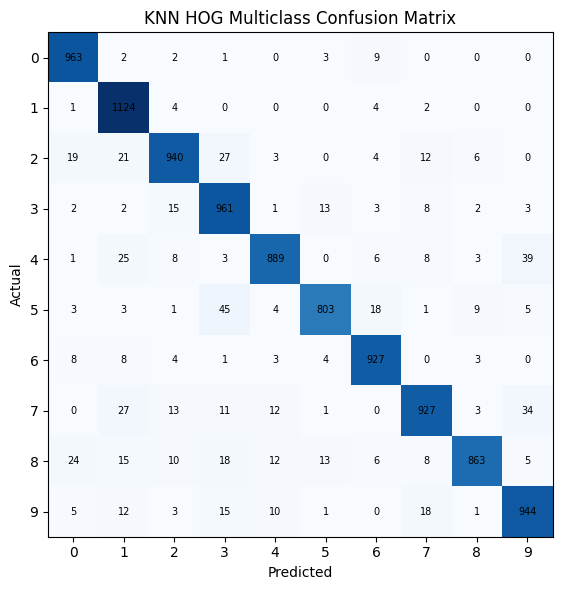

HOG results saved.


In [33]:
save_multiclass_confusion_matrix(
    hog_test_cm,
    "KNN HOG Multiclass Confusion Matrix",
    "../results/phase2/knn_hog_confusion_matrix.png"
)

with open("../results/phase2/knn_hog_results.txt", "w") as f:
    f.write("KNN HOG Phase 2 Results\n")
    f.write("=" * 40 + "\n\n")
    f.write(f"Validation Accuracy: {hog_val_acc:.4f}\n")
    f.write(f"Test Accuracy      : {hog_test_acc:.4f}\n")
    f.write(f"Precision          : {hog_test_prec:.4f}\n")
    f.write(f"Recall             : {hog_test_rec:.4f}\n")
    f.write(f"F1-score           : {hog_test_f1:.4f}\n\n")
    f.write("Test Confusion Matrix:\n")
    f.write(str(hog_test_cm))
    f.write("\n\n")
    f.write(f"Train time: {hog_train_time:.4f}\n")
    f.write(f"Validation time: {hog_val_time:.4f}\n")
    f.write(f"Test time: {hog_test_time:.4f}\n")

print("HOG results saved.")

## Final Feature Comparison

This section compares KNN performance using Flatten, PCA, and HOG features.

The comparison helps determine which feature representation works best for multiclass MNIST classification.

In [34]:
print("=" * 70)
print("PHASE 2 FINAL FEATURE COMPARISON")
print("=" * 70)

print("\n1) Flatten")
print("Validation Accuracy:", flat_val_acc)
print("Test Accuracy      :", flat_test_acc)
print("Test Precision     :", flat_test_prec)
print("Test Recall        :", flat_test_rec)
print("Test F1-score      :", flat_test_f1)

print("\n2) PCA")
print("Validation Accuracy:", pca_val_acc)
print("Test Accuracy      :", pca_test_acc)
print("Test Precision     :", pca_test_prec)
print("Test Recall        :", pca_test_rec)
print("Test F1-score      :", pca_test_f1)

print("\n3) HOG")
print("Validation Accuracy:", hog_val_acc)
print("Test Accuracy      :", hog_test_acc)
print("Test Precision     :", hog_test_prec)
print("Test Recall        :", hog_test_rec)
print("Test F1-score      :", hog_test_f1)

PHASE 2 FINAL FEATURE COMPARISON

1) Flatten
Validation Accuracy: 0.9465
Test Accuracy      : 0.9447
Test Precision     : 0.9449210278544191
Test Recall        : 0.9439394638462663
Test F1-score      : 0.9441177903371987

2) PCA
Validation Accuracy: 0.9666666666666667
Test Accuracy      : 0.9647
Test Precision     : 0.965014310557075
Test Recall        : 0.9643002503925542
Test F1-score      : 0.9644633042021136

3) HOG
Validation Accuracy: 0.9358333333333333
Test Accuracy      : 0.9341
Test Precision     : 0.9361067651420859
Test Recall        : 0.9331827458181594
Test F1-score      : 0.9338798672797374


In [35]:
with open("../results/phase2/knn_phase2_feature_comparison.txt", "w") as f:
    f.write("KNN Phase 2 Feature Comparison\n")
    f.write("=" * 50 + "\n\n")

    f.write("1) Flatten\n")
    f.write(f"Validation Accuracy: {flat_val_acc:.4f}\n")
    f.write(f"Test Accuracy      : {flat_test_acc:.4f}\n")
    f.write(f"Precision          : {flat_test_prec:.4f}\n")
    f.write(f"Recall             : {flat_test_rec:.4f}\n")
    f.write(f"F1-score           : {flat_test_f1:.4f}\n")
    f.write(f"Test time          : {flat_test_time:.4f} sec\n")
    f.write("-" * 50 + "\n\n")

    f.write("2) PCA\n")
    f.write(f"Validation Accuracy: {pca_val_acc:.4f}\n")
    f.write(f"Test Accuracy      : {pca_test_acc:.4f}\n")
    f.write(f"Precision          : {pca_test_prec:.4f}\n")
    f.write(f"Recall             : {pca_test_rec:.4f}\n")
    f.write(f"F1-score           : {pca_test_f1:.4f}\n")
    f.write(f"Test time          : {pca_test_time:.4f} sec\n")
    f.write("-" * 50 + "\n\n")

    f.write("3) HOG\n")
    f.write(f"Validation Accuracy: {hog_val_acc:.4f}\n")
    f.write(f"Test Accuracy      : {hog_test_acc:.4f}\n")
    f.write(f"Precision          : {hog_test_prec:.4f}\n")
    f.write(f"Recall             : {hog_test_rec:.4f}\n")
    f.write(f"F1-score           : {hog_test_f1:.4f}\n")
    f.write(f"Test time          : {hog_test_time:.4f} sec\n")

print("Phase 2 feature comparison saved.")

Phase 2 feature comparison saved.


# Final Conclusion

Among the tested feature extraction methods, PCA achieved the best overall multiclass classification performance with KNN.

PCA reduced dimensionality while preserving important image information, which improved KNN efficiency and accuracy.

Flatten features also produced strong results but were more sensitive to noisy high-dimensional data.

HOG features captured edge information successfully, but performed slightly worse than PCA for MNIST multiclass classification.